In [93]:
import intake
import xarray as xr
import matplotlib.pyplot as plt
from dask_setup import setup_dask_client
import cartopy.crs as ccrs
import numpy as np
import matplotlib as mpl

In [2]:
client, cluster, dask_tmp = setup_dask_client(
    mode="local", workload_type="io", reserve_mem_gb=2
)

INFO     [client] Starting Dask client setup (workload_type=io | environment=jupyter)
INFO     [resources] Resources detected via PBS (total_cores=4 | total_mem_gib=16.0)


INFO     [client] Temp/spill dir: /jobfs/171427572.gadi-pbs/dask-4156059
INFO     [client] Workers: 1 | threads/worker: 4 | processes: False
INFO     [client] Mem: total ~16.0 GiB | usable ~14.0 GiB | per-worker ~14.0 GiB
INFO     [client] Compression: spill=auto | comm=False
INFO     [client] Dask client ready


[setup_dask_client] Configuration summary
temp/spill dir: /jobfs/171427572.gadi-pbs/dask-4156059
Workers: 1 | threads/worker: 4 | processes: False
Memory: total ~16.0 GiB | usable ~14.0 GiB | per-worker ~14.0 GiB
Compression: spill=auto | comm=False


In [3]:
catalog = intake.open_esm_datastore("/g/data/ob53/catalog/v2/esm/catalog.json")

In [17]:
ua100m = catalog.search(
    source_id="BARRA-C2",
    variable_id="ua100m",
    freq="day",
    version="latest",
).to_dask()
va100m = catalog.search(
    source_id="BARRA-C2",
    variable_id="va100m",
    freq="day",
    version="latest",
).to_dask()

In [27]:
ua100m = ua100m["ua100m"]
va100m = va100m["va100m"]

In [105]:
def plot_diff(da1, da2):
    fig, axs = plt.subplots(
        1,
        3,
        figsize=(12, 4),
        sharex=True,
        sharey=True,
        layout="constrained",
        subplot_kw={"projection": ccrs.PlateCarree()},
    )

    meshes = []
    for ax, da in zip(axs, [da1, da2, da2 - da1]):
        meshes.append(
            ax.pcolormesh(da["lon"], da["lat"], da, transform=ccrs.PlateCarree())
        )
        ax.coastlines()

    meshes[1].set_clim(*meshes[0].get_clim())
    for m in meshes[:2]:
        m.set_cmap(mpl.colormaps["viridis"].resampled(8))
    cbars = [
        fig.colorbar(meshes[0], ax=axs[:2]),
        fig.colorbar(meshes[2], ax=axs[2]),
    ]

    clims = meshes[2].get_clim()
    new_clim = max(abs(clims[0]), abs(clims[1]))
    meshes[2].set_clim(-new_clim, new_clim)
    meshes[2].set_cmap(mpl.colormaps["RdBu_r"].resampled(7))

    axs[0].set_xlim(da1["lon"][0], da1["lon"][-1])
    axs[0].set_ylim(da1["lat"][0], da1["lat"][-1])

    return axs, meshes, cbars

In [108]:
def coarsen(da):
    return da.coarsen({"lon": 6, "lat": 6}, boundary="trim").mean()


def n_drought(da, thresh):
    return (da < thresh).sum("time")

In [122]:
REGION = {"lat": slice(-39, -29), "lon": slice(141, 151)}
TIMESPAN = {"time": slice(np.datetime64("2024-01-01"), None)}
sel = {**REGION, **TIMESPAN}
wspd = np.sqrt(ua100m.sel(sel) ** 2 + va100m.sel(sel) ** 2)

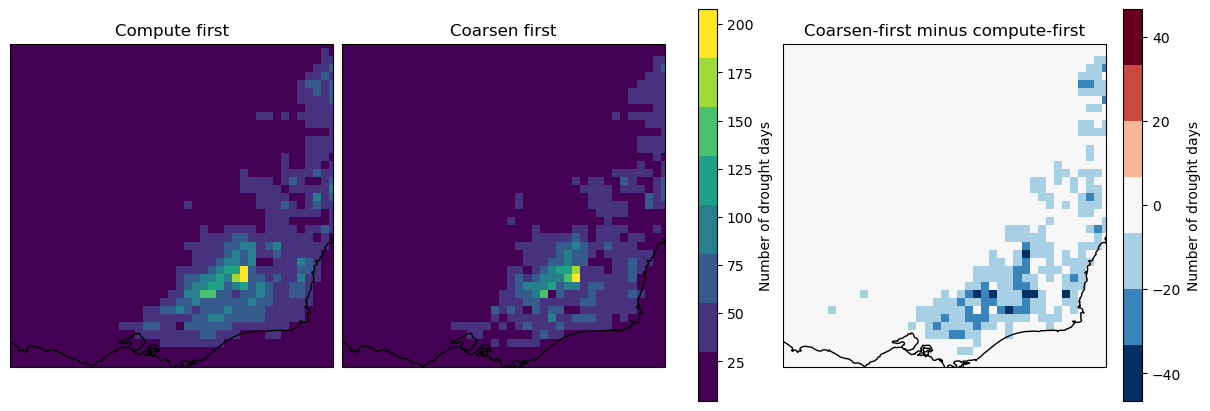

In [111]:
n_drought_compute_coarsen = coarsen(n_drought(wspd, thresh=1.5).compute())
n_drought_coarsen_compute = n_drought(coarsen(wspd).compute(), thresh=1.5)

axs, meshes, cbars = plot_diff(n_drought_compute_coarsen, n_drought_coarsen_compute)
axs[0].set_title("Compute first")
axs[1].set_title("Coarsen first")
axs[2].set_title("Coarsen-first minus compute-first")
for c in cbars:
    c.set_label("Number of drought days")

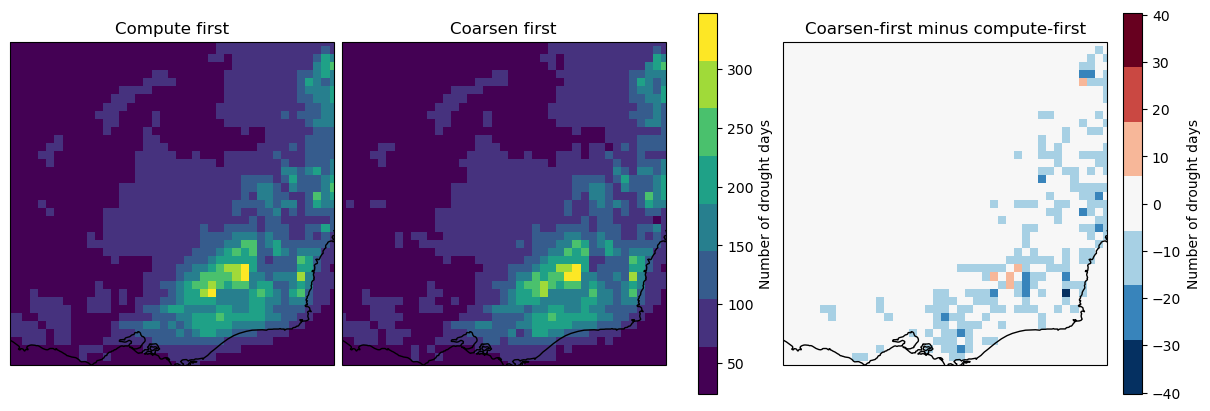

In [109]:
n_drought_compute_coarsen = coarsen(n_drought(wspd, thresh=3.0).compute())
n_drought_coarsen_compute = n_drought(coarsen(wspd).compute(), thresh=3.0)

axs, meshes, cbars = plot_diff(n_drought_compute_coarsen, n_drought_coarsen_compute)
axs[0].set_title("Compute first")
axs[1].set_title("Coarsen first")
axs[2].set_title("Coarsen-first minus compute-first")
for c in cbars:
    c.set_label("Number of drought days")

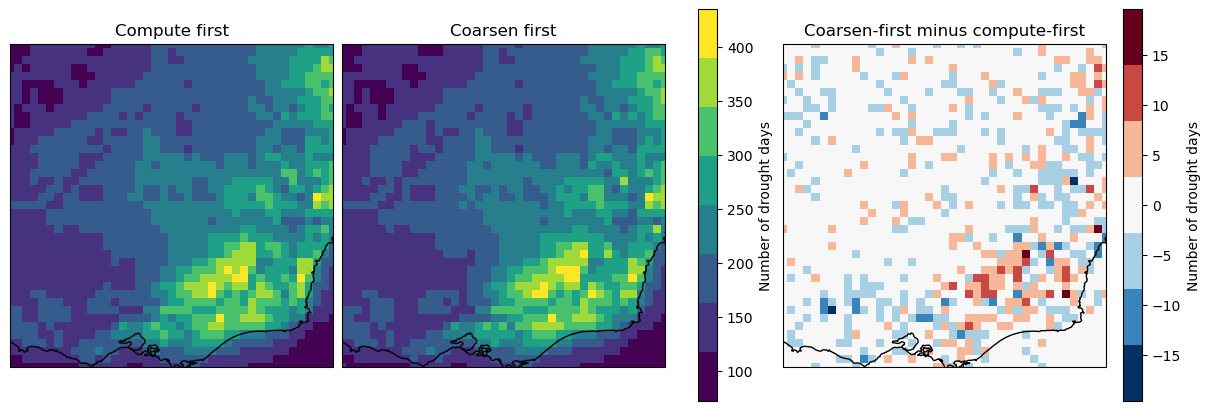

In [110]:
n_drought_compute_coarsen = coarsen(n_drought(wspd, thresh=5.0).compute())
n_drought_coarsen_compute = n_drought(coarsen(wspd).compute(), thresh=5.0)

axs, meshes, cbars = plot_diff(n_drought_compute_coarsen, n_drought_coarsen_compute)
axs[0].set_title("Compute first")
axs[1].set_title("Coarsen first")
axs[2].set_title("Coarsen-first minus compute-first")
for c in cbars:
    c.set_label("Number of drought days")

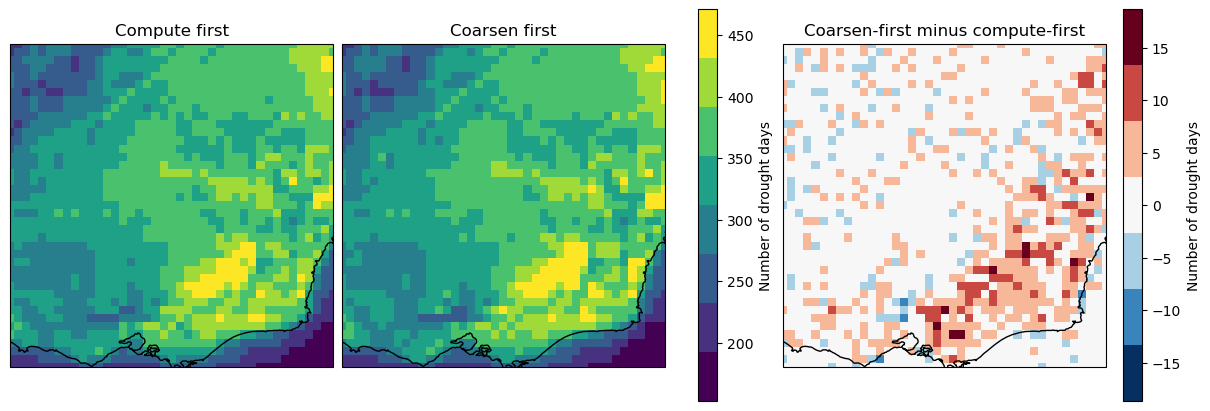

In [112]:
n_drought_compute_coarsen = coarsen(n_drought(wspd, thresh=7.0).compute())
n_drought_coarsen_compute = n_drought(coarsen(wspd).compute(), thresh=7.0)

axs, meshes, cbars = plot_diff(n_drought_compute_coarsen, n_drought_coarsen_compute)
axs[0].set_title("Compute first")
axs[1].set_title("Coarsen first")
axs[2].set_title("Coarsen-first minus compute-first")
for c in cbars:
    c.set_label("Number of drought days")

In [128]:
orog = (
    catalog.search(
        source_id="BARRA-C2",
        variable_id="orog",
        version="latest",
    )
    .to_dask()["orog"]
    .sel(REGION)
)

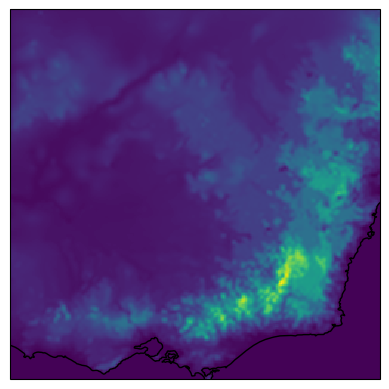

In [130]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
ax.pcolormesh(orog["lon"], orog["lat"], orog)
ax.coastlines()

TODO:
- Average over renewable energy zones?
- Superimpose renewable energy zones
- Repeat on capacity factor